In [ ]:
# 1. Setup and Mount Google Drive

from google.colab import drive
import pandas as pd
import numpy as np
import datetime

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import joblib

drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
# 2. Load Dataset

file_path = '/content/drive/MyDrive/weather_data_only.csv'
df = pd.read_csv(file_path)
print("Dataset loaded. Shape:", df.shape)



Dataset loaded. Shape: (189888, 6)


In [ ]:
# 3. Data Preprocessing

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['hour'] = df['Timestamp'].dt.hour
df['day'] = df['Timestamp'].dt.day
df['month'] = df['Timestamp'].dt.month
df['dayofweek'] = df['Timestamp'].dt.dayofweek
df['year'] = df['Timestamp'].dt.year

feature_cols = ['hour', 'day', 'month', 'dayofweek', 'year']

target_cols = ['Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)',
               'Rainfall (mm)', 'Solar Irradiance (W/m²)']

X = df[feature_cols]
y = df[target_cols]

# Chronological split (important for weather data)
split_idx = int(len(df) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))



Training samples: 151910
Testing samples: 37978


In [ ]:
# 4. Train KNN Regressor

model = KNeighborsRegressor(
    n_neighbors=5,   # you can tune this (3,5,7,10)
    weights='distance'
)

model.fit(X_train, y_train)



KNeighborsRegressor(weights='distance')

In [ ]:
# 5. Predictions

y_pred = model.predict(X_test)



In [ ]:
# 6. Regression Evaluation

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Regression Metrics (KNN) ---")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R2   :", r2)

# Convert each column separately using mean threshold
y_test_bin = (y_test > y_test.mean()).astype(int)
y_pred_bin = (y_pred > y_test.mean().values).astype(int)

# Flatten for overall evaluation (important fix)
y_test_flat = y_test_bin.values.ravel()
y_pred_flat = y_pred_bin.ravel()


# CLASSIFICATION METRICS

print("\n--- Classification Metrics (Converted) ---")

accuracy = accuracy_score(y_test_flat, y_pred_flat)
precision = precision_score(y_test_flat, y_pred_flat, average='macro', zero_division=0)
recall = recall_score(y_test_flat, y_pred_flat, average='macro', zero_division=0)
f1 = f1_score(y_test_flat, y_pred_flat, average='macro', zero_division=0)

# using continuous predictions
roc_auc = roc_auc_score(y_test_flat, y_pred.ravel())

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)




--- Regression Metrics (KNN) ---
MAE  : 10.926492327602507
RMSE : 24.741247841643666
R2   : -0.2046855273715204

--- Classification Metrics (Converted) ---
Accuracy : 0.503954921270209
Precision: 0.5031807617839561
Recall   : 0.5031860518614819
F1 Score : 0.5031311222016641
ROC AUC  : 0.5227871696588657


In [ ]:
# 7. Save Model

joblib.dump(model, 'weather_knn_model.pkl')
print("\nModel saved as 'weather_knn_model.pkl'")




Model saved as 'weather_knn_model.pkl'


In [ ]:
# 8. Prediction Function

def predict_weather(timestamp_str):
    dt = pd.to_datetime(timestamp_str)

    features = pd.DataFrame([[
        dt.hour, dt.day, dt.month, dt.dayofweek, dt.year
    ]], columns=feature_cols)

    pred = model.predict(features)[0]
    return dict(zip(target_cols, pred))


In [ ]:
# 9. Example Prediction

print("\n--- Example Prediction ---")
example = predict_weather('2020-07-01 14:00')

for k, v in example.items():
    print(f"{k}: {v:.2f}")

# 10. Interactive Input

user_input = input("\nEnter timestamp (e.g., 2020-08-15 10:30): ")

try:
    result = predict_weather(user_input)
    print("\nPredicted Weather:")
    for k, v in result.items():
        print(f"{k}: {v:.2f}")
except Exception as e:
    print("Error:", e)


--- Example Prediction ---
Temperature (°C): 29.04
Humidity (%): 82.34
Wind Speed (m/s): 2.27
Rainfall (mm): 0.91
Solar Irradiance (W/m²): 253.09

Enter timestamp (e.g., 2020-08-15 10:30): 2027-10-04   2:10

Predicted Weather:
Temperature (°C): 27.48
Humidity (%): 78.52
Wind Speed (m/s): 1.75
Rainfall (mm): 4.35
Solar Irradiance (W/m²): 273.25


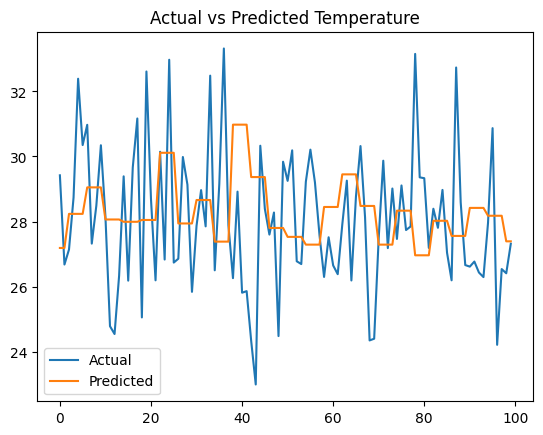

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test['Temperature (°C)'].values[:100], label="Actual")
plt.plot(y_pred[:100, 0], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Temperature")
plt.show()